<a href="https://colab.research.google.com/github/stratbuilds12/demo/blob/main/MIS710A1_Ravalji_226491165.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS710 Machine Learning in Business - Assignment 1
**Student Name:** Dhruvrajsinh Ravalji

**Student ID:** 226491165



# **1. Business Understanding**

**Aim:** The purpose of this notebook is to develop a machine learning solution that will aid UrbanStay in predicting the price for each night’s listing.


- **Context:** The StayWise Analytics (SWA) team has been hired by UrbanStay, a short-term accommodation platform, to explore the determinants of nighttime listing prices.
- **Needs:** Currently, hosts choose their own prices without any data driven support; hence, comparable listings are either overpriced or underpriced leading to lost bookings and lost revenue respectively.
- **Solution:** In order to solve the need, the SWA team presents a supervised regression machine learning model that will predict Nightly Price based on listing, host, and review features, enabling pricing patterns to be derived directly from data.
- **Value Proposition:** The proposed solution is expected to help UrbanStay and its hosts make a defendable and transparent pricing policy, hence increase their booking conversion rates and host revenue.
- **Stakeholders:** The main stakeholders involved include UrbanStay (through Platform Analytics Manager Ms Anisha Kumar), hosts and guests of UrbanStay, all having a vested interest in better and transparent pricing.
- **Change:** The solution, once implemented, will help create pricing guidance to be presented to hosts and will be measured based on consistency in price of comparable listings.

#2 Data Understanding, Preparation, Exploration and Visualisation

## 2.1 Import Libraries

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Mounting drive to google collab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**2.2 Load and Inspect Data**


1.   Load the dataset
2.   Explore the data



In [ ]:
#file path
url="/content/drive/MyDrive/UrbanStay.csv"


In [ ]:
#load dataset
records=pd.read_csv(url)
#explore the dataset
print(records)

      Listing_ID     Host_Name Property_Type      Location  Bedrooms  \
0         997649     Ava Scott        Studio  Outer Suburb         1   
1         990090   Isla Martin     Apartment           CBD         2   
2         995427  Priya Walker     Apartment           CBD         2   
3         996669    Ava Thomas     Townhouse  Inner Suburb         3   
4         990808  Sophie Singh     Townhouse           CBD         2   
...          ...           ...           ...           ...       ...   
6547      996483  David Taylor         House  Outer Suburb         4   
6548      996458  Daniel Singh         House  Outer Suburb         3   
6549      995974     Lily King     Apartment  Inner Suburb         1   
6550      995812      Arjun Le         House  Outer Suburb         5   
6551      995731   Oliver King     Apartment  Inner Suburb         2   

      Bathrooms  Accommodates  Review_Score  Number_of_Reviews Superhost  \
0             2             2          4.50                

In [ ]:
records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Listing_ID         6552 non-null   int64  
 1   Host_Name          6552 non-null   object 
 2   Property_Type      6552 non-null   object 
 3   Location           6552 non-null   object 
 4   Bedrooms           6552 non-null   int64  
 5   Bathrooms          6552 non-null   int64  
 6   Accommodates       6552 non-null   int64  
 7   Review_Score       6356 non-null   float64
 8   Number_of_Reviews  6552 non-null   int64  
 9   Superhost          6552 non-null   object 
 10  Host_Experience    6552 non-null   int64  
 11  Cleaning_Fee       6408 non-null   float64
 12  Minimum_Nights     6552 non-null   int64  
 13  Amenities_Score    6454 non-null   float64
 14  Instant_Bookable   6552 non-null   object 
 15  Nightly_Price      6552 non-null   float64
dtypes: float64(4), int64(7),

In [ ]:
records.head()

,Listing_ID,Host_Name,Property_Type,Location,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Superhost,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Instant_Bookable,Nightly_Price
0,997649,Ava Scott,Studio,Outer Suburb,1,2,2,4.50,68,No,6,52.0,5,6.0,Yes,165.42
1,990090,Isla Martin,Apartment,CBD,2,2,4,4.72,22,No,0,48.0,2,6.0,Yes,382.85
2,995427,Priya Walker,Apartment,CBD,2,2,3,4.50,47,Yes,1,32.0,2,6.0,No,276.28
3,996669,Ava Thomas,Townhouse,Inner Suburb,3,3,6,4.55,68,Yes,4,76.0,2,6.0,No,318.71
4,990808,Sophie Singh,Townhouse,CBD,2,2,4,4.58,85,Yes,15,42.0,1,4.0,Yes,357.58


##2.3 Data Quality Assesment

In [ ]:
# determining the missing value
records.isnull().sum()

,0
Listing_ID,0
Host_Name,0
Property_Type,0
Location,0
Bedrooms,0
Bathrooms,0
Accommodates,0
Review_Score,196
Number_of_Reviews,0
Superhost,0


In [ ]:
# Overview of numeric data
records.describe()

,Listing_ID,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Host_Experience,Cleaning_Fee,Minimum_Nights,Amenities_Score,Nightly_Price
count,6552.000000,6552.000000,6552.000000,6552.000000,6356.000000,6552.000000,6552.000000,6408.000000,6552.000000,6454.000000,6552.000000
mean,993994.124695,2.221764,1.931319,4.826923,4.444421,51.124695,4.191697,64.003901,2.349969,5.726526,302.983562
std,2306.109824,1.198558,0.716286,2.538777,0.262024,37.789277,3.830503,18.032491,1.833162,1.673594,107.639074
min,990003.000000,1.000000,1.000000,1.000000,3.380000,0.000000,0.000000,18.000000,1.000000,1.000000,55.000000
25%,991992.750000,1.000000,1.000000,3.000000,4.270000,24.000000,1.000000,50.000000,1.000000,5.000000,220.985000
50%,993986.500000,2.000000,2.000000,4.000000,4.450000,43.000000,3.000000,63.000000,2.000000,6.000000,295.825000
75%,995990.250000,3.000000,2.000000,7.000000,4.630000,68.000000,6.000000,76.000000,3.000000,7.000000,376.735000
max,998000.000000,5.000000,4.000000,10.000000,5.000000,317.000000,15.000000,129.000000,14.000000,10.000000,808.540000


In [ ]:
records.duplicated().sum()

np.int64(52)

## 2.4 Data Cleaning and Preperation

In [ ]:
#Duplicate rows were removed to ensure each listing is represented only once in the dataset.
records.drop_duplicates(inplace=True)
print(f"Shape of records after dropping duplicates: {records.shape}")

Shape of records after dropping duplicates: (6500, 16)


In [ ]:
print("Property_Type values:", records['Property_Type'].unique())
print("Location values:", records['Location'].unique())
print("Superhost values:", records['Superhost'].unique())
print("Instant_Bookable values:", records['Instant_Bookable'].unique())

Property_Type values: ['Studio' 'Apartment' 'Townhouse' 'House' 'Villa' 'Studio ' 'apartment'
 'villa' 'Town House' 'HOUSE']
Location values: ['Outer Suburb' 'CBD' 'Inner Suburb' 'Regional']
Superhost values: ['No' 'Yes' 'N' 'Y']
Instant_Bookable values: ['Yes' 'No']


In [ ]:
# standardizing the property type categorical value.
records['Property_Type'] = records['Property_Type'].str.strip().str.lower()

property_type_mapping = {
    'apartment': 'Apartment',
    'house': 'House',
    'studio': 'Studio',
    'townhouse': 'Townhouse',
    'town house': 'Townhouse',
    'villa': 'Villa'
}

records['Property_Type'] = records['Property_Type'].replace(property_type_mapping)


print(records['Property_Type'].unique())

['Studio' 'Apartment' 'Townhouse' 'House' 'Villa']


In [ ]:
#standardizing the super host values
superhost_mapping = {
    'Y': 'Yes',
    'N': 'No',
    'Yes': 'Yes',
    'No': 'No'
}

records['Superhost'] = records['Superhost'].replace(superhost_mapping)


print(records['Superhost'].unique())

['No' 'Yes']


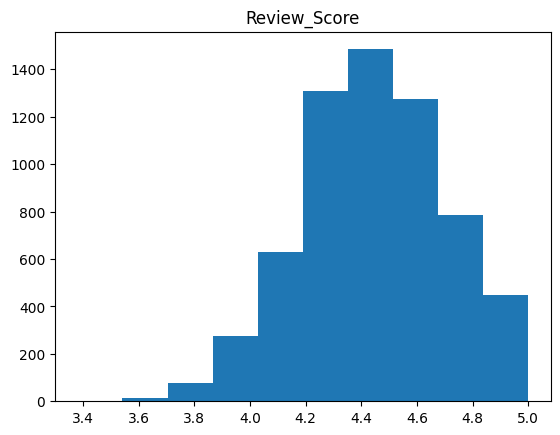

Review_Score — mean: 4.44, median: 4.45


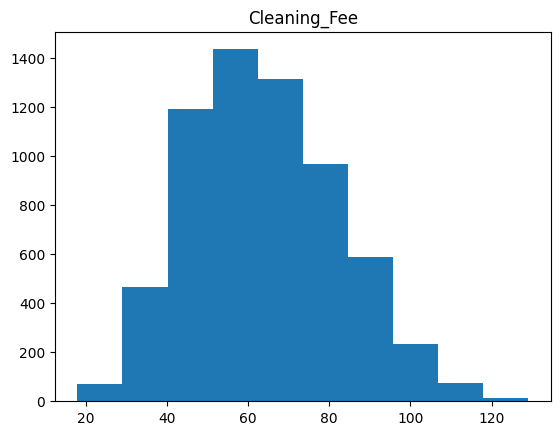

Cleaning_Fee — mean: 63.97, median: 63.00


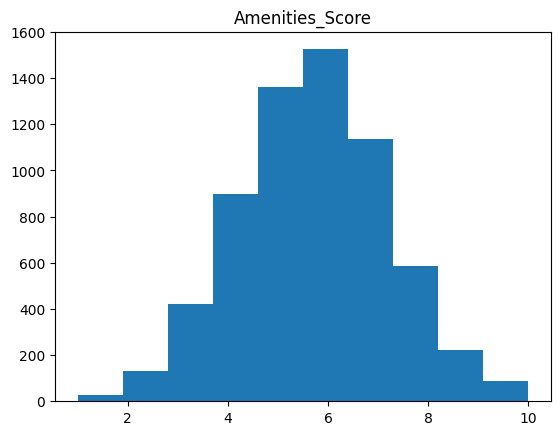

Amenities_Score — mean: 5.73, median: 6.00


In [ ]:
# Checking the distribution shape for three columns with null values.
for col in ['Review_Score', 'Cleaning_Fee', 'Amenities_Score']:
    plt.hist(records[col].dropna())
    plt.title(col)
    plt.show()
    print(f"{col} — mean: {records[col].mean():.2f}, median: {records[col].median():.2f}")

In [ ]:
# As the mean and median values are near to each other mean is used for the imputation.
records['Review_Score'] = records['Review_Score'].fillna(records['Review_Score'].mean())
records['Cleaning_Fee'] = records['Cleaning_Fee'].fillna(records['Cleaning_Fee'].mean())
records['Amenities_Score'] = records['Amenities_Score'].fillna(records['Amenities_Score'].mean())
print(records.isnull().sum())

Listing_ID           0
Host_Name            0
Property_Type        0
Location             0
Bedrooms             0
Bathrooms            0
Accommodates         0
Review_Score         0
Number_of_Reviews    0
Superhost            0
Host_Experience      0
Cleaning_Fee         0
Minimum_Nights       0
Amenities_Score      0
Instant_Bookable     0
Nightly_Price        0
dtype: int64


In [ ]:
#dropping the unpredictive column
records = records.drop(["Listing_ID", "Host_Name"], axis=1)

# Confirm they're gone
print(records.columns)

Index(['Property_Type', 'Location', 'Bedrooms', 'Bathrooms', 'Accommodates',
       'Review_Score', 'Number_of_Reviews', 'Superhost', 'Host_Experience',
       'Cleaning_Fee', 'Minimum_Nights', 'Amenities_Score', 'Instant_Bookable',
       'Nightly_Price'],
      dtype='object')


In [ ]:
# Final checking
print("Shape:", records.shape)
print("Duplicates remaining:", records.duplicated().sum())
print("Missing values remaining:\n", records.isnull().sum())
print(records.dtypes)

Shape: (6500, 14)
Duplicates remaining: 0
Missing values remaining:
 Property_Type        0
Location             0
Bedrooms             0
Bathrooms            0
Accommodates         0
Review_Score         0
Number_of_Reviews    0
Superhost            0
Host_Experience      0
Cleaning_Fee         0
Minimum_Nights       0
Amenities_Score      0
Instant_Bookable     0
Nightly_Price        0
dtype: int64
Property_Type         object
Location              object
Bedrooms               int64
Bathrooms              int64
Accommodates           int64
Review_Score         float64
Number_of_Reviews      int64
Superhost             object
Host_Experience        int64
Cleaning_Fee         float64
Minimum_Nights         int64
Amenities_Score      float64
Instant_Bookable      object
Nightly_Price        float64
dtype: object


_NOTE : This above dataset was cleaned by standardising the inconsistent category labels in property_types and superhost, imputingthe missing values in three column using mean and removing unpredictive column. This dataset is now eady for exploratory Analysis._

##2.5 Univariate Analysis

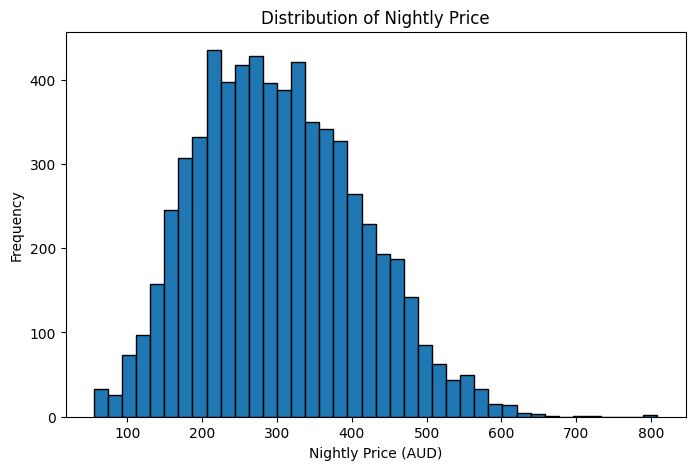

In [ ]:
#histogram of Nightly price
plt.figure(figsize=(8,5))

plt.hist(records['Nightly_Price'], bins=40, edgecolor='black')
plt.title('Distribution of Nightly Price')
plt.xlabel('Nightly Price (AUD)')
plt.ylabel('Frequency')
plt.show()

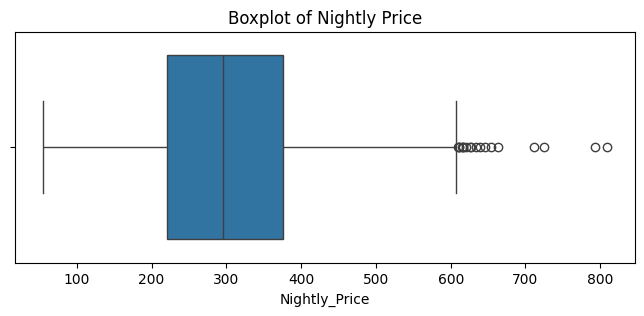

In [ ]:
# Box plot of Nightly price
plt.figure(figsize=(8,3))
sns.boxplot(x=records['Nightly_Price'])
plt.title('Boxplot of Nightly Price')
plt.show()

In [ ]:
print(records['Nightly_Price'].describe())
print("Skewness:", records['Nightly_Price'].skew().round(2))

count    6500.000000
mean      302.859788
std       107.598286
min        55.000000
25%       220.935000
50%       295.690000
75%       376.442500
max       808.540000
Name: Nightly_Price, dtype: float64
Skewness: 0.35


Nightly_Price shows a right-skewed distribution with a small number of high-priced
premium listings pulling the mean above the median. Most listings cluster in the
lower-to-mid price range, which is consistent with a market dominated by standard
apartment and studio listings rather than luxury properties.

In [ ]:
# frequency count for categorical values
categorical_cols = ['Property_Type', 'Location', 'Superhost', 'Instant_Bookable']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(records[col].value_counts())
    print(records[col].value_counts(normalize=True).round(3))


--- Property_Type ---
Property_Type
Apartment    2580
House        1757
Studio       1018
Townhouse     811
Villa         334
Name: count, dtype: int64
Property_Type
Apartment    0.397
House        0.270
Studio       0.157
Townhouse    0.125
Villa        0.051
Name: proportion, dtype: float64

--- Location ---
Location
Inner Suburb    2067
Outer Suburb    1901
CBD             1382
Regional        1150
Name: count, dtype: int64
Location
Inner Suburb    0.318
Outer Suburb    0.292
CBD             0.213
Regional        0.177
Name: proportion, dtype: float64

--- Superhost ---
Superhost
No     4123
Yes    2377
Name: count, dtype: int64
Superhost
No     0.634
Yes    0.366
Name: proportion, dtype: float64

--- Instant_Bookable ---
Instant_Bookable
Yes    3867
No     2633
Name: count, dtype: int64
Instant_Bookable
Yes    0.595
No     0.405
Name: proportion, dtype: float64


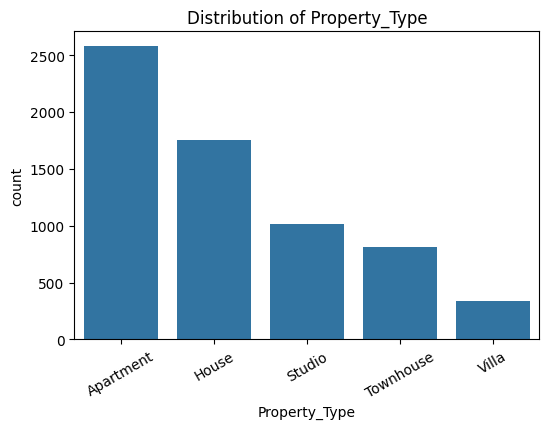

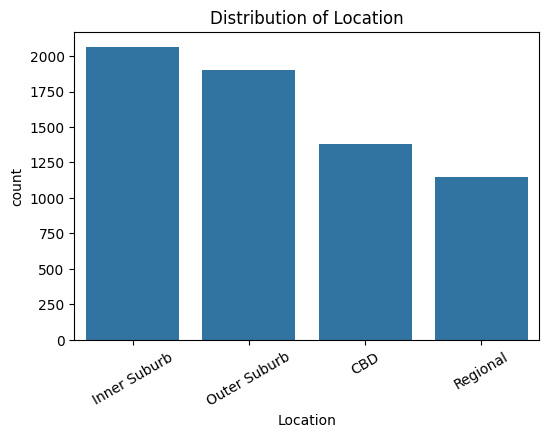

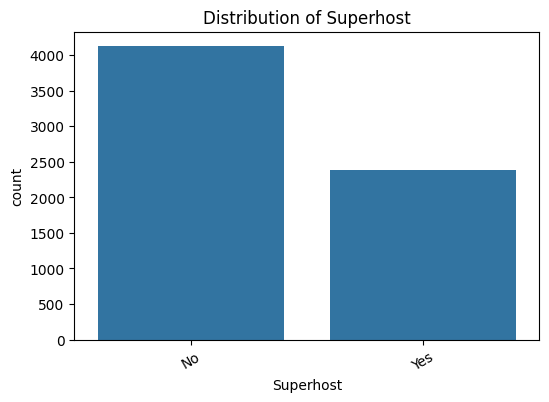

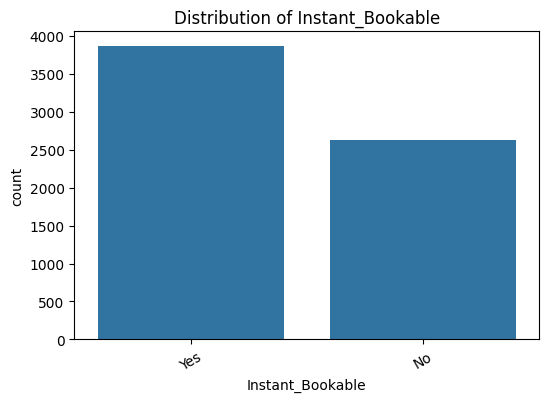

In [ ]:
# Bar chartsfor categorical values.
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=records, x=col, order=records[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)
    plt.show()

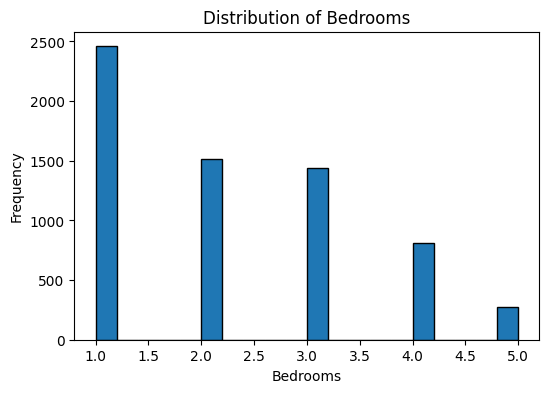

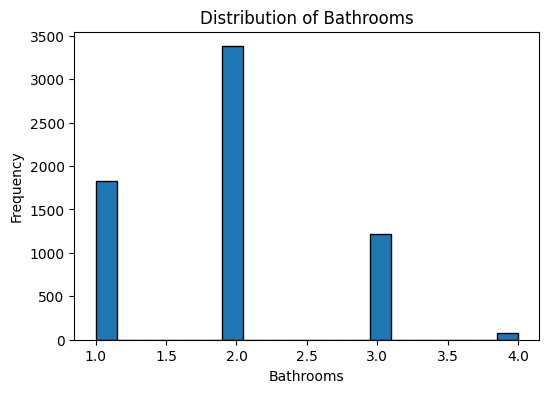

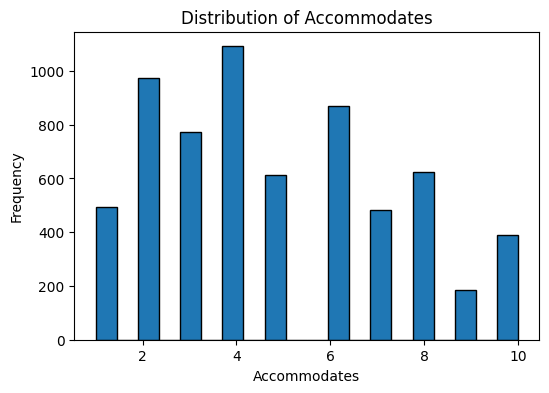

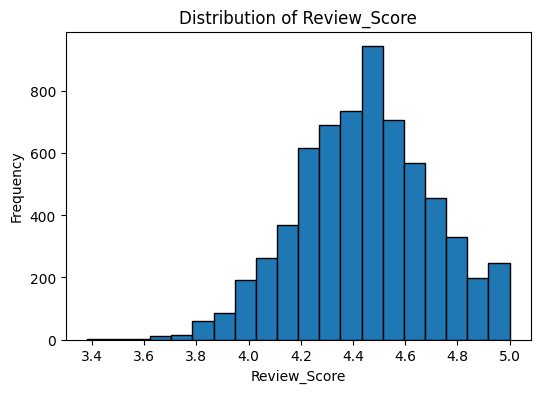

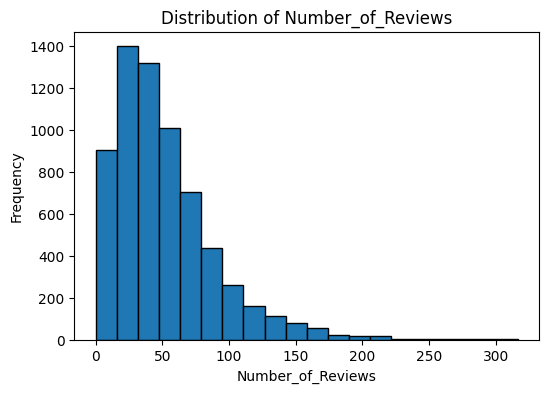

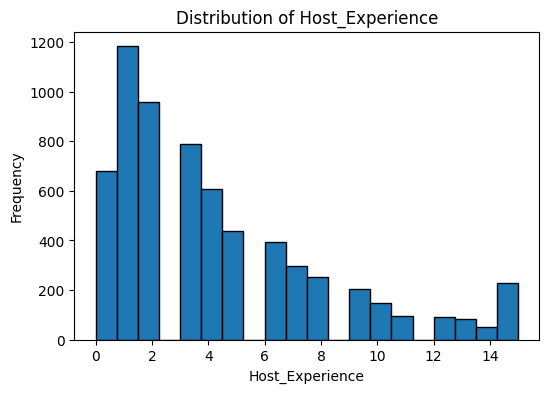

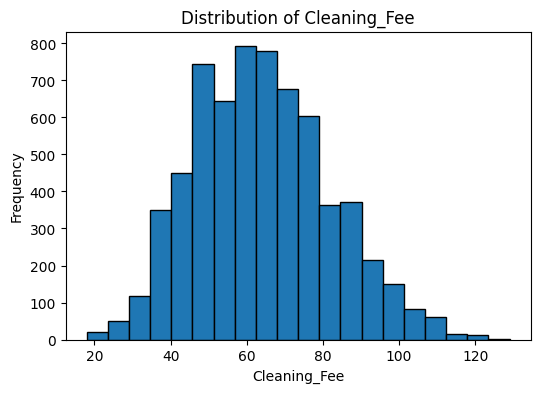

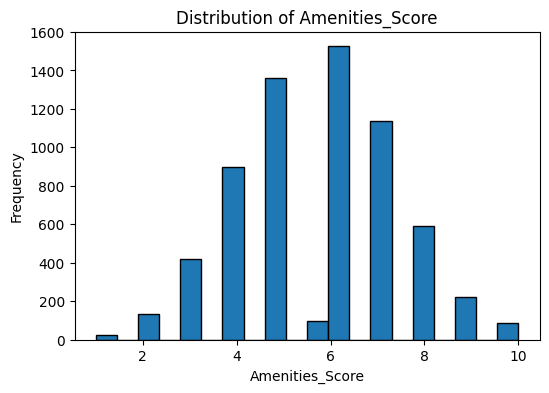

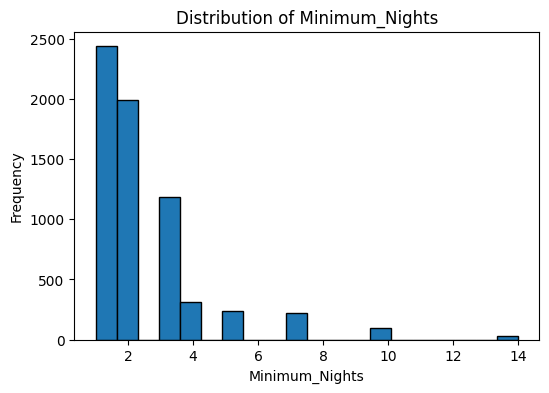

In [ ]:
# Distribution of numeric variables
numeric_cols = ['Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score',
                 'Number_of_Reviews', 'Host_Experience', 'Cleaning_Fee',
                 'Amenities_Score', 'Minimum_Nights']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(records[col], bins=20, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
records[numeric_cols + ['Nightly_Price']].describe()

,Bedrooms,Bathrooms,Accommodates,Review_Score,Number_of_Reviews,Host_Experience,Cleaning_Fee,Amenities_Score,Minimum_Nights,Nightly_Price
count,6500.00000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000
mean,2.22000,1.930154,4.824615,4.444266,51.118000,4.189538,63.973415,5.727117,2.351231,302.859788
std,1.19723,0.716058,2.536578,0.257841,37.795081,3.825605,17.831262,1.661650,1.834813,107.598286
min,1.00000,1.000000,1.000000,3.380000,0.000000,0.000000,18.000000,1.000000,1.000000,55.000000
25%,1.00000,1.000000,3.000000,4.280000,24.000000,1.000000,51.000000,5.000000,1.000000,220.935000
50%,2.00000,2.000000,4.000000,4.444266,43.000000,3.000000,63.000000,6.000000,2.000000,295.690000
75%,3.00000,2.000000,7.000000,4.620000,68.000000,6.000000,76.000000,7.000000,3.000000,376.442500
max,5.00000,4.000000,10.000000,5.000000,317.000000,15.000000,129.000000,10.000000,14.000000,808.540000


##2.6 Bivariate Analysis

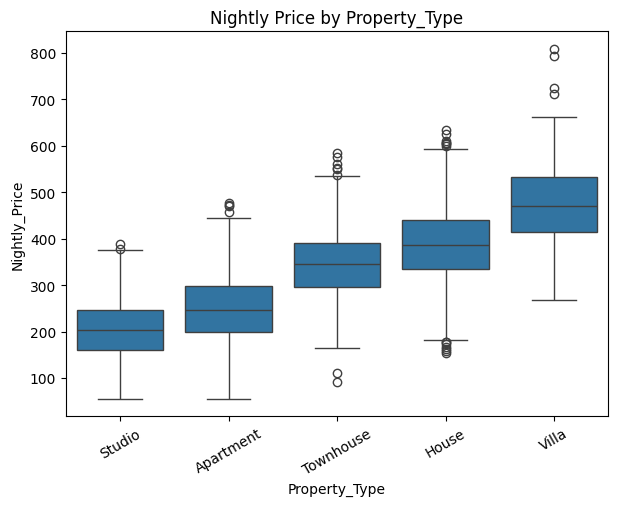

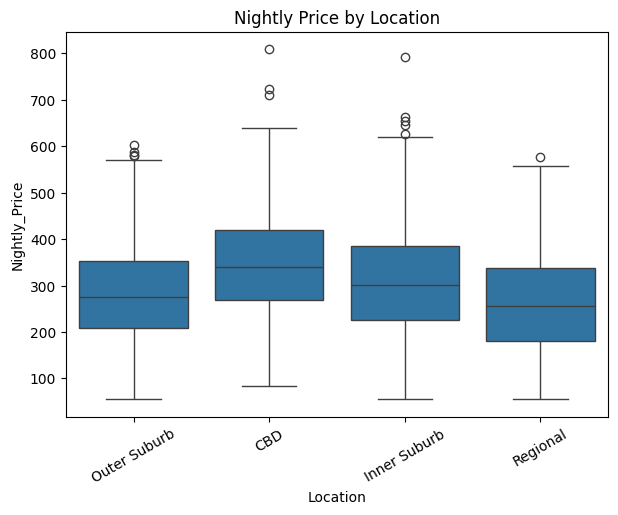

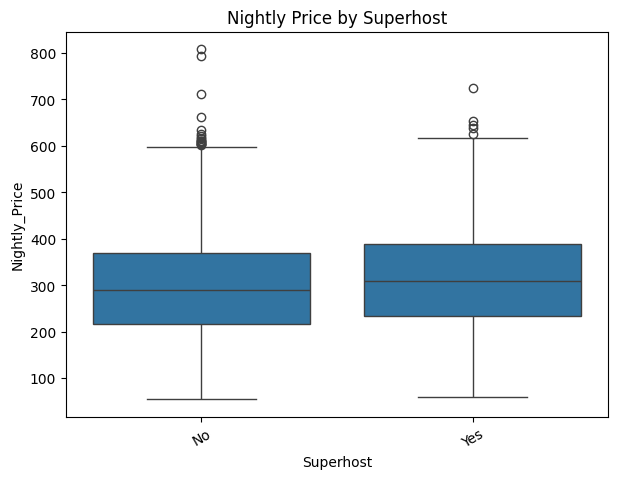

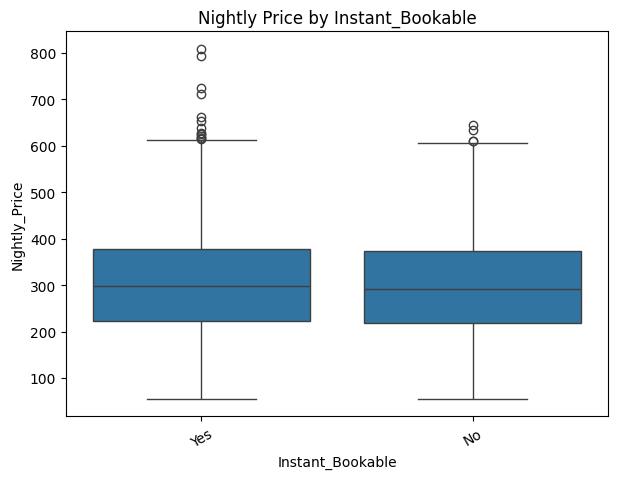

In [ ]:
#Nightly_Price vs categorical variables
categorical_cols = ['Property_Type', 'Location', 'Superhost', 'Instant_Bookable']

for col in categorical_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=records, x=col, y='Nightly_Price')
    plt.title(f'Nightly Price by {col}')
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
# median price per category
for col in categorical_cols:
    print(f"\n--- Median Nightly_Price by {col} ---")
    print(records.groupby(col)['Nightly_Price'].median().sort_values(ascending=False))


--- Median Nightly_Price by Property_Type ---
Property_Type
Villa        469.840
House        386.940
Townhouse    345.560
Apartment    245.740
Studio       203.125
Name: Nightly_Price, dtype: float64

--- Median Nightly_Price by Location ---
Location
CBD             340.29
Inner Suburb    301.64
Outer Suburb    275.17
Regional        256.56
Name: Nightly_Price, dtype: float64

--- Median Nightly_Price by Superhost ---
Superhost
Yes    308.52
No     288.91
Name: Nightly_Price, dtype: float64

--- Median Nightly_Price by Instant_Bookable ---
Instant_Bookable
Yes    298.16
No     291.75
Name: Nightly_Price, dtype: float64


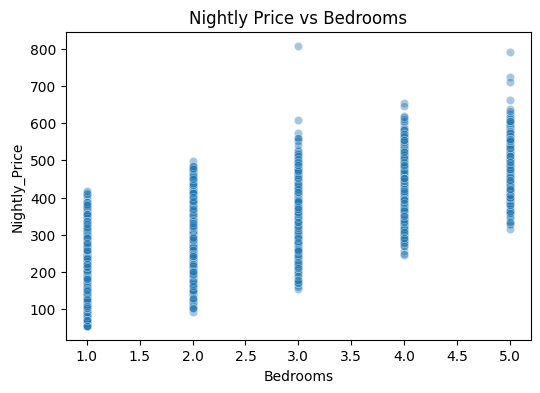

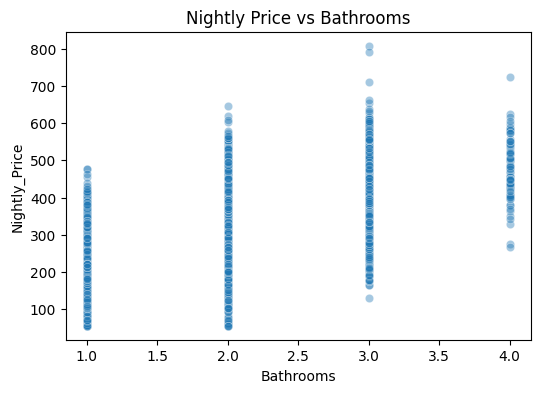

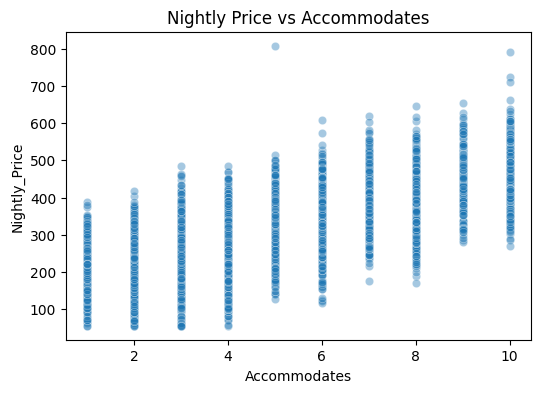

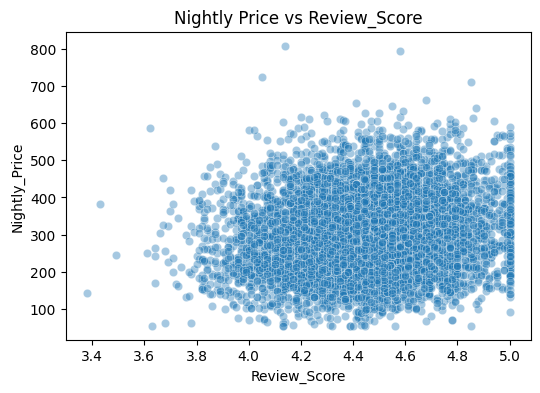

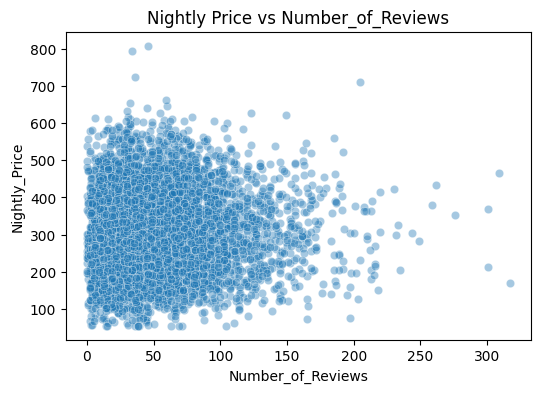

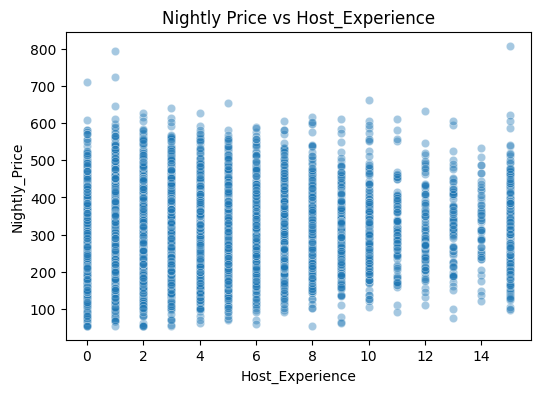

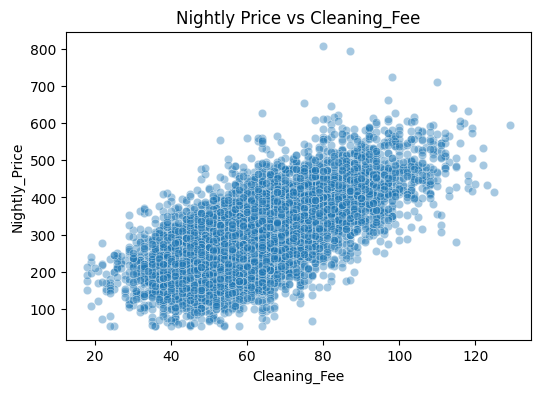

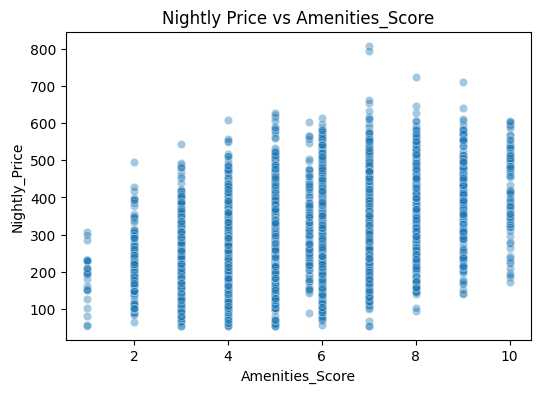

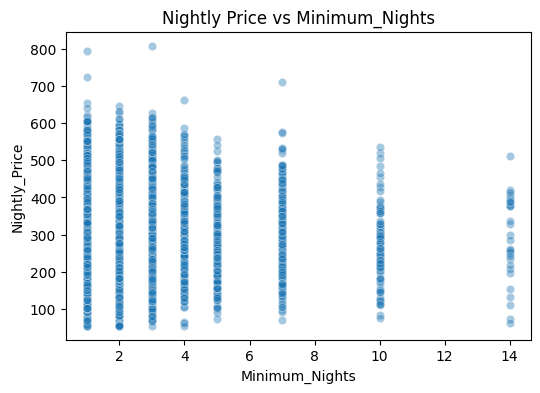

In [ ]:
# Nightly price vs Numeric Variables
numeric_cols = ['Bedrooms', 'Bathrooms', 'Accommodates', 'Review_Score',
                 'Number_of_Reviews', 'Host_Experience', 'Cleaning_Fee',
                 'Amenities_Score', 'Minimum_Nights']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=records, x=col, y='Nightly_Price', alpha=0.4)
    plt.title(f'Nightly Price vs {col}')
    plt.show()

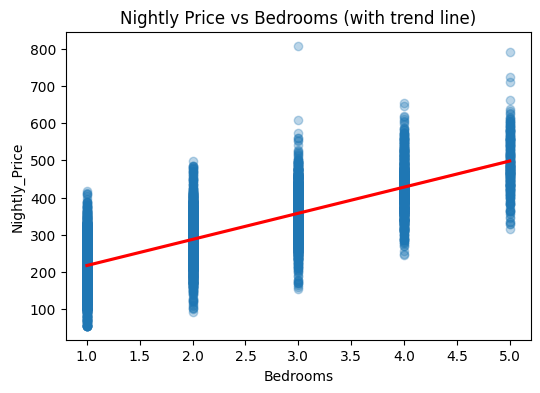

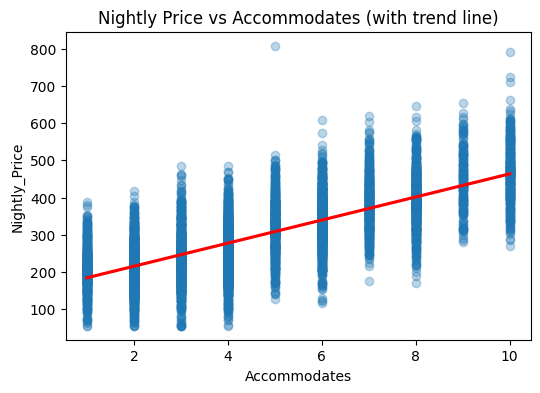

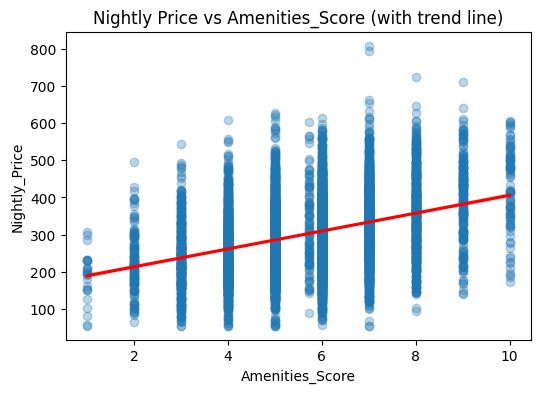

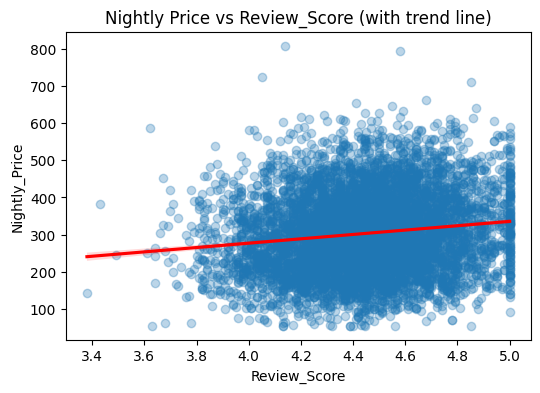

In [ ]:
# Regression trend line on top
for col in ['Bedrooms', 'Accommodates', 'Amenities_Score', 'Review_Score']:
    plt.figure(figsize=(6,4))
    sns.regplot(data=records, x=col, y='Nightly_Price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Nightly Price vs {col} (with trend line)')
    plt.show()

## 2.7 Multivariate Analysis

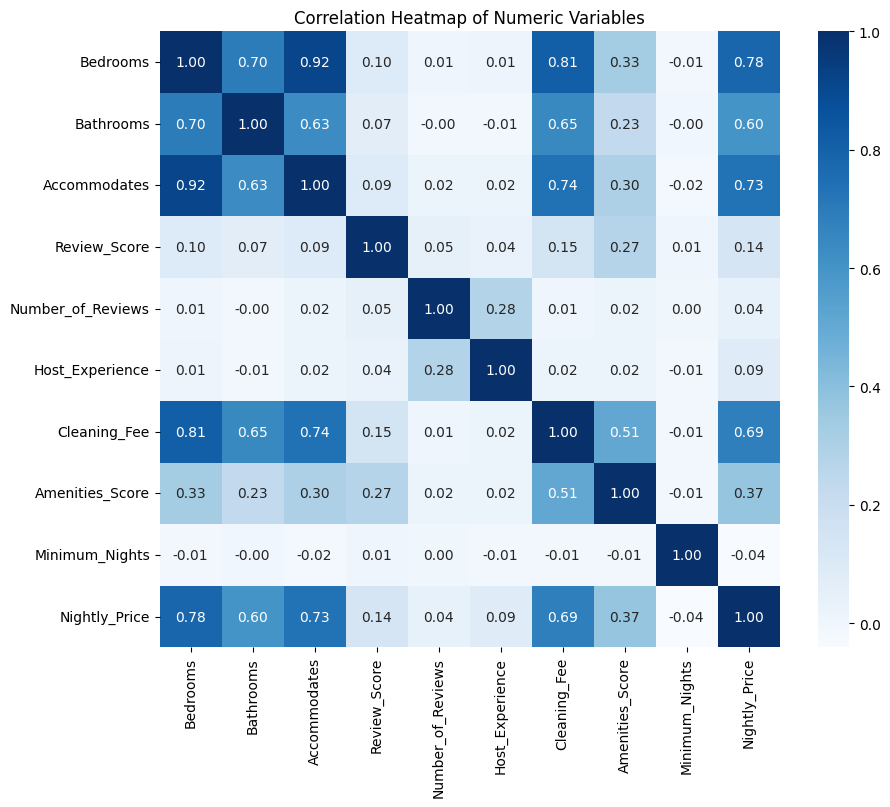

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr_matrix = records[numeric_cols + ['Nightly_Price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [ ]:
price_corr = corr_matrix['Nightly_Price'].sort_values(ascending=False)
print(price_corr)

Nightly_Price        1.000000
Bedrooms             0.782136
Accommodates         0.732540
Cleaning_Fee         0.686399
Bathrooms            0.599070
Amenities_Score      0.371883
Review_Score         0.140583
Host_Experience      0.085602
Number_of_Reviews    0.042779
Minimum_Nights      -0.040893
Name: Nightly_Price, dtype: float64


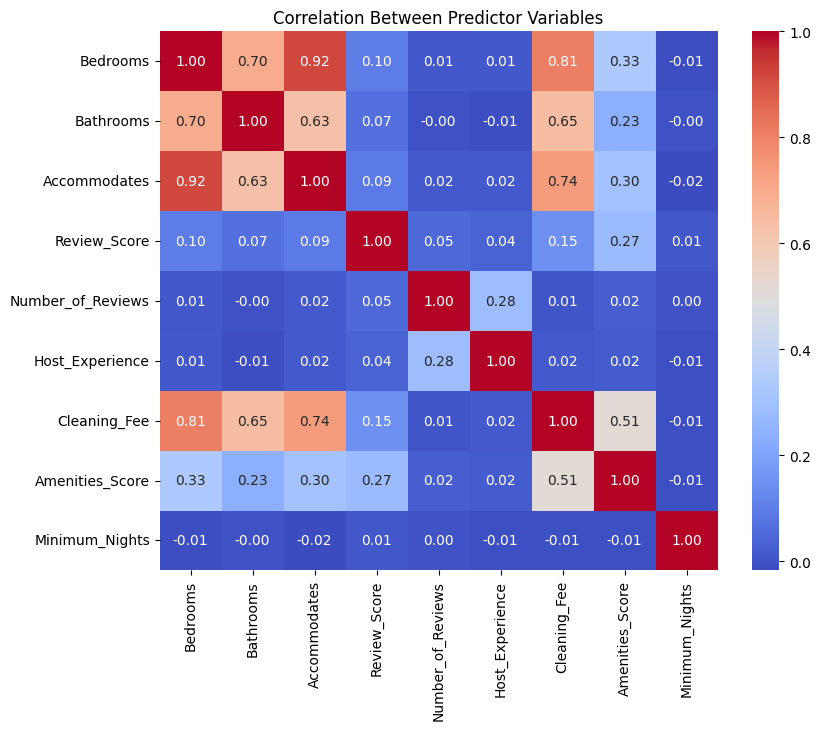

In [ ]:
#corelation map between variables
predictor_corr = records[numeric_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(predictor_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Predictor Variables')
plt.show()

# 3.Machine Learning Model Development

##3.1 Feature and Target Selection

In [ ]:
features = ['Bedrooms','Accommodates', 'Bathrooms', 'Cleaning_Fee', 'Amenities_Score',
            'Review_Score', 'Host_Experience', 'Number_of_Reviews',
            'Property_Type', 'Location','Superhost',  'Instant_Bookable']

X = records[features].copy()
y = records['Nightly_Price']

print(X.shape)
print(X.dtypes)

(6500, 12)
Bedrooms               int64
Accommodates           int64
Bathrooms              int64
Cleaning_Fee         float64
Amenities_Score      float64
Review_Score         float64
Host_Experience        int64
Number_of_Reviews      int64
Property_Type         object
Location              object
Superhost             object
Instant_Bookable      object
dtype: object


##3.2 Feature Encoding and Scaling

In [ ]:
# hot encoding multicategory variables
X = pd.get_dummies(X, columns=['Property_Type', 'Location'], drop_first=True)

In [ ]:
#converting categories into binary
X['Superhost'] = X['Superhost'].map({'Yes': 1, 'No': 0})
X['Instant_Bookable'] = X['Instant_Bookable'].map({'Yes': 1, 'No': 0})

##3.3 Train-Test split

In [ ]:
# distributing data for training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5200, 17)
Test set: (1300, 17)


##3.4 Model Training

In [ ]:
# training data
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
# Inspecting the model's coefficients
coefs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coefs)
print("Intercept:", model.intercept_)

Property_Type_Villa        106.950828
Property_Type_House         51.571739
Property_Type_Townhouse     34.896766
Bedrooms                    27.997132
Bathrooms                   15.264289
Review_Score                10.157142
Superhost                    7.663292
Amenities_Score              6.172497
Instant_Bookable             4.677272
Accommodates                 3.853277
Host_Experience              2.139459
Cleaning_Fee                 0.289624
Number_of_Reviews            0.006608
Property_Type_Studio       -19.819360
Location_Inner Suburb      -34.452677
Location_Outer Suburb      -62.960271
Location_Regional          -84.369595
dtype: float64
Intercept: 102.44451159929167


# 4.Model Evaluation and post Analysis

##4.1 Model Performance Metrics

In [ ]:
# determining the performance matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 43.92
RMSE: 54.72
R²: 0.732


In [ ]:
# Comparing y_prediction distribution against y_test distribution
print("Actual (y_test) stats:")
print(y_test.describe())

print("\nPredicted (y_pred) stats:")
print(pd.Series(y_pred).describe())

Actual (y_test) stats:
count    1300.000000
mean      300.141723
std       105.665951
min        55.000000
25%       219.200000
50%       292.500000
75%       368.845000
max       645.720000
Name: Nightly_Price, dtype: float64

Predicted (y_pred) stats:
count    1300.000000
mean      300.576686
std        92.162132
min       127.195144
25%       224.303972
50%       285.177104
75%       369.653736
max       593.729772
dtype: float64


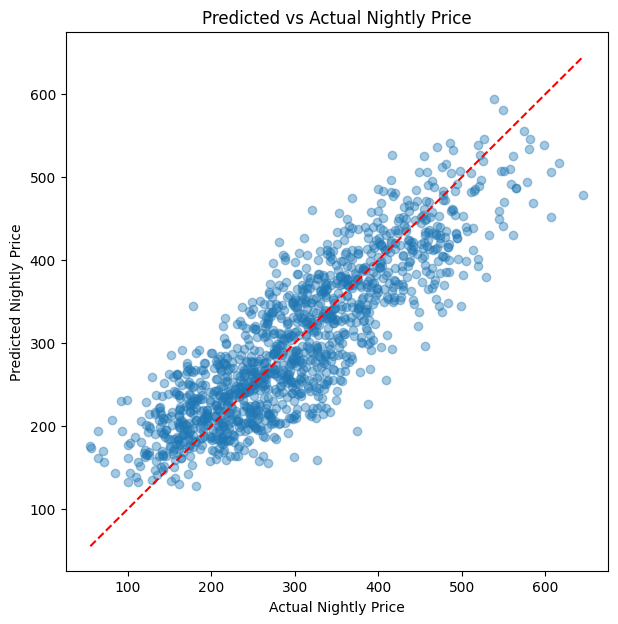

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Nightly Price')
plt.ylabel('Predicted Nightly Price')
plt.title('Predicted vs Actual Nightly Price')
plt.show()

##4.2 Residual Analysis

In [ ]:
# residual calculation
residuals = y_test - y_pred
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Residual skew:", residuals.skew())

Residual mean: -0.4349627872871462
Residual std: 54.741845214663634
Residual skew: 0.15988211464798635


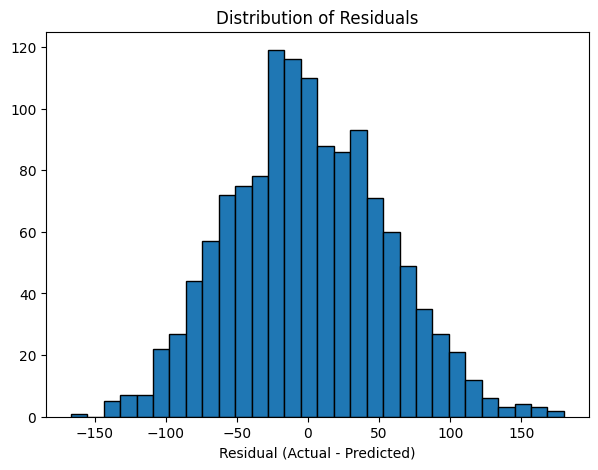

In [ ]:
#visualisation of residuals
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

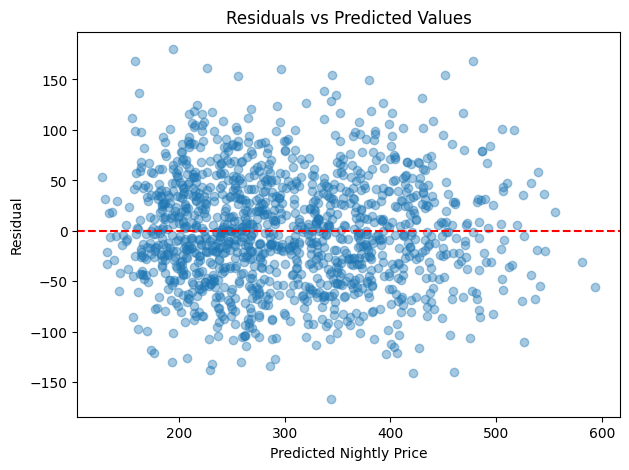

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Nightly Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.show()